# Lab 6: TerraTorch

#### `TorchGeo`

- 🎯 A **domain library** providing geo-spatial pre-trained models, **datasets**, transforms and samplers.
- 📖 [https://torchgeo.readthedocs.io/en/stable/](https://torchgeo.readthedocs.io/en/stable/)
- 📂 [https://github.com/torchgeo/torchgeo](https://github.com/torchgeo/torchgeo)
- 📚 [https://deepwiki.com/microsoft/torchgeo](https://deepwiki.com/microsoft/torchgeo)

#### `TerraTorch`

- 🎯 A **fine-tuning toolkit** for geo-spatial foundation models (GFMs) **built on top of `torchgeo`**.
- 📖 [https://terrastackai.github.io/terratorch/stable/](https://terrastackai.github.io/terratorch/stable/)
- 📂 [https://github.com/terrastackai/terratorch](https://github.com/terrastackai/terratorch)
- 📚 [https://deepwiki.com/terrastackai/terratorch](https://deepwiki.com/terrastackai/terratorch)

## Geo-spatial Foundation Models (GFMs)

Large deep-learning models **pre-trained with self-supervision**.

![Prithvi 2.0](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-600M/resolve/main/assets/model_architecture.png)

*Prithvi-EO-2.0: A Versatile Multi-Temporal Foundation Model for Earth Observation Applications. [https://doi.org/10.48550/arXiv.2412.02732](https://doi.org/10.48550/arXiv.2412.02732)*

- Pre-training GFMs from scratch is intractable.
- Fine-tuning GFMs is streamline by existing domain libraries/frameworks.



In [55]:
import importlib.metadata
import os
from collections.abc import Sequence
from functools import lru_cache
from pathlib import Path
from pprint import pprint
from typing import Any, Callable, ClassVar, Literal, Self

import lightning.pytorch as pl
import numpy as np
import terratorch
import torch
import torchgeo
import torchvision
import yaml
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split

In [56]:
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"TorchGeo version: {torchgeo.__version__}")
print(f"TerraTorch version: {importlib.metadata.version('terratorch')}")

PyTorch version: 2.11.0+cu130
TorchVision version: 0.26.0+cu130
TorchGeo version: 0.9.0
TerraTorch version: 1.2.6


In [57]:
USER = os.getenv("USER")
SCRATCH = os.getenv("SCRATCH")

DATA_ROOT = Path(f"{SCRATCH}/{USER}/data")
TRAINING_DATA_DIR = DATA_ROOT / "training_data"

assert TRAINING_DATA_DIR.exists(), TRAINING_DATA_DIR

%matplotlib inline

## Utils

### Dataset

In [58]:
def _parse_npz_file(file_path):
    return np.load(file_path).values()


def get_class_distribution(dataset):
    distribution = {
        label.item(): count.item()
        for label, count in zip(*dataset.labels.unique(return_counts=True))
    }
    sorted_distribution = {
        k: v
        for k, v in sorted(distribution.items(), key=lambda item: item[1], reverse=True)
    }

    return sorted_distribution

In [59]:
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    48: "No data",
}

# Color mapping for visualization
CORINE_COLORS = {
    1: "#E6004D",
    2: "#FF0000",
    3: "#CC4DF2",
    4: "#CC0000",
    5: "#E6CCCC",
    6: "#E6CCE6",
    7: "#A600CC",
    8: "#A64DCC",
    9: "#FF4DFF",
    10: "#FFA6FF",
    11: "#FFE6FF",
    12: "#FFFFA8",
    13: "#FFFF00",
    14: "#E6E600",
    15: "#E68000",
    16: "#F2A64D",
    17: "#E6A600",
    18: "#E6E64D",
    19: "#FFE6A6",
    20: "#FFE64D",
    21: "#E6CC4D",
    22: "#F2CCA6",
    23: "#80FF00",
    24: "#00A600",
    25: "#4DFF00",
    26: "#CCF24D",
    27: "#A6FF80",
    28: "#A6E64D",
    29: "#A6F200",
    30: "#E6E6E6",
    31: "#CCCCCC",
    32: "#CCFFCC",
    33: "#000000",
    34: "#A6E6CC",
    35: "#A6A6FF",
    36: "#4D4DFF",
    37: "#CCCCFF",
    38: "#E6E6FF",
    39: "#A6A6E6",
    40: "#00CCF2",
    41: "#80F2E6",
    42: "#00FFA6",
    43: "#A6FFE6",
    44: "#E6F2FF",
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


### Splitting

In [60]:
def get_split(
    sample_indices: torch.Tensor, ratios: list[float], generator: torch.Generator
) -> tuple[torch.Tensor, ...]:

    from math import floor

    if len(ratios) == 2:
        _, test_ratio = ratios
        val_ratio = None
    elif len(ratios) == 3:
        _, val_ratio, test_ratio = ratios
    else:
        raise ValueError(
            "Wrong number of ratios provided. Only 2 or 3 ratio values are admitted."
        )

    num_test = max(1, floor(test_ratio * len(sample_indices)))
    num_val = max(1, floor(val_ratio * len(sample_indices))) if val_ratio else 0
    num_train = len(sample_indices) - num_test - num_val

    assert num_train + num_val + num_test == len(sample_indices), (
        "Ratios do not ensure full coverage of samples."
    )

    random_indices = torch.randperm(len(sample_indices), generator=generator)
    slices = [
        slice(0, num_train),
        slice(num_train, num_train + num_val),
        slice(num_train + num_val, num_train + num_val + num_test),
    ]
    train_indices, val_indices, test_indices = [
        sample_indices[random_indices[s]] for s in slices
    ]

    if val_indices.numel() == 0:
        return train_indices, test_indices
    return train_indices, val_indices, test_indices

In [61]:
def make_splits_train_val_test(
    dataset: torch.Tensor,
    labels: torch.Tensor,
    train_frac: float = 0.9,
    val_frac: float = 0.05,
    test_frac: float = 0.05,
    seed: int = 42,
    stratify: bool = True,
) -> tuple[Subset, ...]:
    """
    Train/Val/Test split with optional stratification.

    Requirements:
      train_frac + val_frac + test_frac == 1.0
    """
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train_frac + val_frac + test_frac must be 1.0"

    ratios = [train_frac, val_frac, test_frac]
    generator = torch.Generator().manual_seed(seed)

    if not stratify:
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, ratios, generator=generator
        )
        return train_dataset, val_dataset, test_dataset

    # labels = dataset.labels
    class_indices = [
        torch.argwhere(labels == label).flatten() for label in labels.unique()
    ]
    class_splits = [
        get_split(indices, ratios=ratios, generator=generator)
        for indices in class_indices
    ]
    subset_indices = map(torch.cat, zip(*class_splits))

    return tuple([Subset(dataset, index_set) for index_set in subset_indices])

## Configuration

In [62]:
with open(Path() / "lab6_config.yaml", mode="r", encoding="utf-8") as src:
    cfg = yaml.safe_load(src)

pprint(cfg)

{'data': {'sampling_strategy': 'weighted',
          'split_strategy': 'stratified',
          'test_ratio': 0.05,
          'train_ratio': 0.9,
          'transforms': {'train': None, 'val': None},
          'val_ratio': 0.05},
 'model': {'in_channels': 4, 'patch_size': 224},
 'training': {'batch_size': 32, 'epochs': 1, 'lr': 1e-05}}


## TerraTorch Workflow

```mermaid
flowchart LR
    A[Data module] --> B[Trainer]
    C[Task] --> B
```

## Data module

Custom dataset implementing the [`NonGeoClassificationDataset`](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#nongeoclassificationdataset) interface from `torchgeo`

```mermaid
flowchart LR
    subgraph A [torchgeo.NonGeoDataModule]
        direction TB
        A1[torchgeo.NonGeoClassificationDataset]
    end
```  

### Dataset folder structure

A `NonGeoClassificationDataset` expects the following folder layout

```shell
.
├── train
│   ├── agriculture_with_natural_vegetation
│   ├── broad_leaved_forest
│   ├── complex_cultivation_patterns
│   ├── coniferous_forest
│   ├── discontinuous_urban_fabric
│   ├── industrial_or_commercial_units
│   ├── mixed_forest
│   ├── non_irrigated_arable_land
│   ├── pastures
│   └── water_bodies
├── val
│   ├── agriculture_with_natural_vegetation
│   ├── broad_leaved_forest
│   ├── complex_cultivation_patterns
│   ├── coniferous_forest
│   ├── discontinuous_urban_fabric
│   ├── industrial_or_commercial_units
│   ├── mixed_forest
│   ├── non_irrigated_arable_land
│   ├── pastures
│   └── water_bodies
└── test
    ├── agriculture_with_natural_vegetation
    ├── broad_leaved_forest
    ├── complex_cultivation_patterns
    ├── coniferous_forest
    ├── discontinuous_urban_fabric
    ├── industrial_or_commercial_units
    ├── mixed_forest
    ├── non_irrigated_arable_land
    ├── pastures
    └── water_bodies
```

In [63]:
class CorineDatasetProcessor:
    """
    Custom Dataset for remote sensing data.

    Parameters:
    -----------
    data : torch.Tensor
        Feature data (n_samples, n_channels, patch_height, patch_width)
    labels : torch.Tensor
        Target labels (n_samples,)
    """

    corine_classes = CORINE_CLASSES

    @classmethod
    def from_npz(cls, folder_path):
        file_paths = folder_path.glob("*_data.npz")
        data, labels = map(np.concatenate, zip(*map(_parse_npz_file, file_paths)))

        return cls(torch.tensor(data), torch.tensor(labels))

    def __init__(self, data: torch.Tensor, labels: torch.Tensor):

        self.data = data
        self.original_labels = labels

        self.unique_original_labels = self.original_labels.unique()
        self.label_mapping = {
            lbl.item(): i for i, lbl in enumerate(self.unique_original_labels)
        }
        self.reverse_label_mapping = {
            i: lbl.item() for i, lbl in enumerate(self.unique_original_labels)
        }
        self.labels = torch.tensor(
            [self.label_mapping[lbl.item()] for lbl in labels]
        ).type_as(self.original_labels)
        self.unique_labels = self.labels.unique()

        self.class_names = {
            self.label_mapping[lbl.item()]: self.corine_classes[lbl.item()]
            for lbl in self.unique_original_labels
        }

    def drop_labels(self, blacklist: list[int], use_original: bool = True) -> Self:
        if use_original:
            blacklist = [self.reverse_label_mapping[label] for label in blacklist]
        blacklist = torch.tensor(blacklist).type_as(self.original_labels)
        keep_indices = ~torch.isin(self.original_labels, blacklist)
        filtered_data, filtered_orig_labels = (
            self.data[keep_indices],
            self.original_labels[keep_indices],
        )

        return type(self)(filtered_data, filtered_orig_labels)

    def _format_class_name(self, class_name: str) -> str:
        replacements = ((" ", "_"), ("-", "_"))

        for old, new in replacements:
            class_name = class_name.strip().replace(old, new)

        return class_name.lower()

    # TODO: make root folder a ContextVar
    def create_class_folder(self, root: Path, class_name: str) -> Path:

        folder_name = self._format_class_name(class_name)
        folder_path = root / folder_name
        folder_path.mkdir(parents=True)

        return folder_path.resolve()

    def create_imagefolder_structure(
        self, root: os.PathLike | Path, split: str
    ) -> dict[int, Path]:
        split_folder = Path(root) / split
        class_folder_router = {
            idx: self.create_class_folder(split_folder, class_name)
            for idx, class_name in self.class_names.items()
        }

        return class_folder_router

    def save_split(self, split_indices: Subset, root: os.PathLike | Path, split: str):
        folder_router = self.create_imagefolder_structure(root, split)
        data, labels = self.data[split_indices], self.labels[split_indices]

        assert len(data) == len(labels) and len(data) > 0

        for idx, patch, label in zip(split_indices, data, labels):
            np.save(folder_router[label.item()] / f"{idx}.npy", patch.numpy())

    def make_splits(self, root: os.PathLike | Path, **kwargs):
        stratify = kwargs.get("split_strategy", "random") == "stratified"

        subsets = make_splits_train_val_test(
            self.data,
            self.labels,
            train_frac=kwargs["train_ratio"],
            val_frac=kwargs["val_ratio"],
            test_frac=kwargs["test_ratio"],
            stratify=stratify,
        )
        '''
        for subset, split in zip(subsets, ["train", "val", "test"]):
            self.save_split(subset.indices, root, split)
        '''

        return subsets

In [64]:
print(TRAINING_DATA_DIR)

/p/scratch/training2600/hilmarsson1/data/training_data


In [65]:
processor = CorineDatasetProcessor.from_npz(TRAINING_DATA_DIR)

In [66]:
processor.class_names

{0: 'Continuous urban fabric',
 1: 'Discontinuous urban fabric',
 2: 'Industrial or commercial units',
 3: 'Mineral extraction sites',
 4: 'Sport and leisure facilities',
 5: 'Non-irrigated arable land',
 6: 'Permanently irrigated land',
 7: 'Rice fields',
 8: 'Vineyards',
 9: 'Fruit trees and berry plantations',
 10: 'Olive groves',
 11: 'Pastures',
 12: 'Annual crops with permanent crops',
 13: 'Complex cultivation patterns',
 14: 'Agriculture with natural vegetation',
 15: 'Agro-forestry areas',
 16: 'Broad-leaved forest',
 17: 'Coniferous forest',
 18: 'Mixed forest',
 19: 'Natural grasslands',
 20: 'Moors and heathland',
 21: 'Sclerophyllous vegetation',
 22: 'Transitional woodland-shrub',
 23: 'Burnt areas',
 24: 'Salt marshes',
 25: 'Intertidal flats',
 26: 'Water courses',
 27: 'Water bodies',
 28: 'Estuaries'}

In [67]:
class_distribution = get_class_distribution(processor)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(processor.label_mapping)

Labels distribution
{16: 2059, 22: 1731, 15: 1178, 18: 775, 13: 626, 6: 562, 10: 522, 21: 303, 14: 263, 17: 191, 12: 154, 8: 145, 7: 133, 5: 110, 11: 66, 1: 44, 28: 31, 9: 30, 27: 25, 20: 21, 2: 14, 0: 11, 19: 8, 24: 7, 26: 6, 3: 4, 23: 4, 25: 4, 4: 2}

Mapping
{1: 0, 2: 1, 3: 2, 7: 3, 11: 4, 12: 5, 13: 6, 14: 7, 15: 8, 16: 9, 17: 10, 18: 11, 19: 12, 20: 13, 21: 14, 22: 15, 23: 16, 24: 17, 25: 18, 26: 19, 27: 20, 28: 21, 29: 22, 33: 23, 37: 24, 39: 25, 40: 26, 41: 27, 43: 28}


In [68]:
blacklist = [idx for idx in class_distribution if class_distribution[idx] < 10]
print(blacklist)

[19, 24, 26, 3, 23, 25, 4]


In [69]:
processor = processor.drop_labels(blacklist)
class_distribution = get_class_distribution(processor)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(processor.label_mapping)

Labels distribution
{14: 2059, 19: 1731, 13: 1178, 16: 775, 11: 626, 4: 562, 8: 522, 18: 303, 12: 263, 15: 191, 10: 154, 6: 145, 5: 133, 3: 110, 9: 66, 1: 44, 21: 31, 7: 30, 20: 25, 17: 21, 2: 14, 0: 11}

Mapping
{1: 0, 2: 1, 3: 2, 12: 3, 13: 4, 14: 5, 15: 6, 16: 7, 17: 8, 18: 9, 19: 10, 20: 11, 21: 12, 22: 13, 23: 14, 24: 15, 25: 16, 27: 17, 28: 18, 29: 19, 41: 20, 43: 21}


In [70]:
dataset_folder = Path(DATA_ROOT / "processed")
train_subset, val_subset, test_subset = processor.make_splits(
    dataset_folder, **cfg["data"]
)
print(DATA_ROOT)

/p/scratch/training2600/hilmarsson1/data


In [71]:
print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_subset)}")
train_labels = processor.labels[train_subset.indices]
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_subset)}")
val_labels = processor.labels[val_subset.indices]
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_subset)}")
test_labels = processor.labels[test_subset.indices]
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 8110
# Training labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 442
# Validation labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 442
# Test labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


In [72]:
# --- 5) Sanity check label distribution ---
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)
    print(f"\n{name} label distribution (top {topk}):")
    for v, c in zip(vals[order][:topk], cnts[order][:topk]):
        orig = processor.reverse_label_mapping[int(v)]
        print(f"  idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (top 10):
  idx 14 (CORINE 23): 1855
  idx 19 (CORINE 29): 1559
  idx 13 (CORINE 22): 1062
  idx 16 (CORINE 25): 699
  idx 11 (CORINE 20): 564
  idx  4 (CORINE 13): 506
  idx  8 (CORINE 17): 470
  idx 18 (CORINE 28): 273
  idx 12 (CORINE 21): 237
  idx 15 (CORINE 24): 173

Val label distribution (top 10):
  idx 14 (CORINE 23): 102
  idx 19 (CORINE 29): 86
  idx 13 (CORINE 22): 58
  idx 16 (CORINE 25): 38
  idx 11 (CORINE 20): 31
  idx  4 (CORINE 13): 28
  idx  8 (CORINE 17): 26
  idx 18 (CORINE 28): 15
  idx 12 (CORINE 21): 13
  idx 15 (CORINE 24): 9

Test label distribution (top 10):
  idx 14 (CORINE 23): 102
  idx 19 (CORINE 29): 86
  idx 13 (CORINE 22): 58
  idx 16 (CORINE 25): 38
  idx 11 (CORINE 20): 31
  idx  4 (CORINE 13): 28
  idx  8 (CORINE 17): 26
  idx 18 (CORINE 28): 15
  idx 12 (CORINE 21): 13
  idx 15 (CORINE 24): 9


In [73]:
assert set() == set(train_subset.indices.tolist()) & set(val_subset.indices.tolist())
assert set() == set(val_subset.indices.tolist()) & set(test_subset.indices.tolist())
assert set() == set(train_subset.indices.tolist()) & set(test_subset.indices.tolist())

### Dataset class

In [74]:
from torchgeo.datasets import NonGeoClassificationDataset


class CorineDataset(NonGeoClassificationDataset):
    splits = ("train", "val", "test")
    valid_extensions = (".npy", ".npz", ".safetensors")

    def __init__(
        self,
        root: Path,
        split: Literal["train", "val", "test"],
        transforms: Callable[[Any], Any] | None = None,
    ) -> None:

        self.split = split

        def is_valid_file(path: str) -> bool:
            return Path(path).suffix in self.valid_extensions

        super().__init__(
            root=root / self.split,
            transforms=transforms,
            loader=np.load,
            is_valid_file=is_valid_file,
        )

    def compute_class_weights(self):
        # TODO: automatically detect format
        samples_per_class = [
            len(list((self.root / class_name).glob("*.npy")))
            for class_name in self.classes
        ]
        class_weights = torch.reciprocal(
            torch.tensor(samples_per_class, dtype=torch.float64)
        )
        weights_mapping = {idx: value.item() for idx, value in enumerate(class_weights)}

        return weights_mapping

In [75]:
train_dataset = CorineDataset(root=dataset_folder, split="train")
val_dataset = CorineDataset(root=dataset_folder, split="val")
test_dataset = CorineDataset(root=dataset_folder, split="test")

In [76]:
train_class_dist = sorted(
    [
        (class_name, len(list((train_dataset.root / class_name).glob("*.npy"))))
        for class_name in train_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

val_class_dist = sorted(
    [
        (class_name, len(list((val_dataset.root / class_name).glob("*.npy"))))
        for class_name in val_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

test_class_dist = sorted(
    [
        (class_name, len(list((test_dataset.root / class_name).glob("*.npy"))))
        for class_name in test_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

In [77]:


reverse_classnames = {
    name.strip().replace(" ", "_").replace("-", "_").lower(): idx
    for idx, name in processor.class_names.items()
}

'''

assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in train_class_dist
] == [12, 18, 24, 25, 2, 41, 23, 20, 21, 3]
assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in val_class_dist
] == [12, 18, 24, 25, 2, 41, 20, 23, 21, 3]
assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in test_class_dist
] == [12, 18, 24, 25, 2, 41, 20, 23, 21, 3]

'''

'\n\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in train_class_dist\n] == [12, 18, 24, 25, 2, 41, 23, 20, 21, 3]\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in val_class_dist\n] == [12, 18, 24, 25, 2, 41, 20, 23, 21, 3]\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in test_class_dist\n] == [12, 18, 24, 25, 2, 41, 20, 23, 21, 3]\n\n'

In [78]:
import itertools

train_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (train_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in train_dataset.classes
            ]
        )
    )
).type_as(train_subset.indices)
assert torch.equal(
    torch.sort(train_subset.indices)[0], torch.sort(train_class_indices)[0]
)

import itertools

val_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (val_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in val_dataset.classes
            ]
        )
    )
).type_as(val_subset.indices)
assert torch.equal(torch.sort(val_subset.indices)[0], torch.sort(val_class_indices)[0])

import itertools

test_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (test_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in test_dataset.classes
            ]
        )
    )
).type_as(test_subset.indices)
assert torch.equal(
    torch.sort(test_subset.indices)[0], torch.sort(test_class_indices)[0]
)

torch.Size([224, 224, 4])


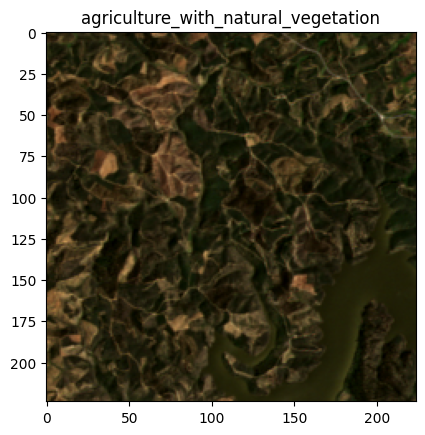

In [79]:
sample = train_dataset[81]

arr = sample["image"].permute(2, 1, 0)
print(arr.shape)
rgb = arr[:, :, [2, 1, 0]]
rgb = np.clip(rgb, 0, 1)  # Ensure in [0, 1]
plt.imshow(rgb * 1.5)
plt.title(train_dataset.classes[sample["label"].item()])
plt.show()

In [80]:

remap_names, remap_indices = zip(
    *sorted(list(reverse_classnames.items()), key=lambda item: item[0])
)
assert list(remap_names) == train_dataset.classes
print(remap_indices)


(12, 13, 10, 14, 11, 15, 0, 1, 21, 7, 2, 16, 17, 3, 8, 9, 4, 5, 18, 19, 6, 20)


In [81]:
class_weights = train_dataset.compute_class_weights()
pprint(class_weights)

{0: 0.004219409282700422,
 1: 0.0009416195856873823,
 2: 0.007142857142857143,
 3: 0.0005390835579514825,
 4: 0.0017730496453900709,
 5: 0.005780346820809248,
 6: 0.1111111111111111,
 7: 0.025,
 8: 0.034482758620689655,
 9: 0.03571428571428571,
 10: 0.08333333333333333,
 11: 0.001430615164520744,
 12: 0.05263157894736842,
 13: 0.01,
 14: 0.002127659574468085,
 15: 0.016666666666666666,
 16: 0.001976284584980237,
 17: 0.008264462809917356,
 18: 0.003663003663003663,
 19: 0.0006414368184733803,
 20: 0.007633587786259542,
 21: 0.043478260869565216}


In [82]:
verify = {
    0: 0.005780346691608429,
    1: 0.10000000149011612,
    2: 0.0002258355962112546,
    3: 0.0005611672531813383,
    4: 0.00917431153357029,
    5: 0.03125,
    6: 0.00917431153357029,
    7: 0.0010537407360970974,
    8: 0.0018214936135336757,
    9: 0.007299270015209913,
}
pprint(verify)

{0: 0.005780346691608429,
 1: 0.10000000149011612,
 2: 0.0002258355962112546,
 3: 0.0005611672531813383,
 4: 0.00917431153357029,
 5: 0.03125,
 6: 0.00917431153357029,
 7: 0.0010537407360970974,
 8: 0.0018214936135336757,
 9: 0.007299270015209913}


In [83]:
'''
for idx, val in enumerate(remap_indices):
    assert abs(verify[val] - class_weights[idx]) < 1e-8
'''

KeyError: 12

In [84]:
pprint(dict(zip(train_dataset.classes, class_weights.values())))

{'agriculture_with_natural_vegetation': 0.004219409282700422,
 'agro_forestry_areas': 0.0009416195856873823,
 'annual_crops_with_permanent_crops': 0.007142857142857143,
 'broad_leaved_forest': 0.0005390835579514825,
 'complex_cultivation_patterns': 0.0017730496453900709,
 'coniferous_forest': 0.005780346820809248,
 'continuous_urban_fabric': 0.1111111111111111,
 'discontinuous_urban_fabric': 0.025,
 'estuaries': 0.034482758620689655,
 'fruit_trees_and_berry_plantations': 0.03571428571428571,
 'industrial_or_commercial_units': 0.08333333333333333,
 'mixed_forest': 0.001430615164520744,
 'moors_and_heathland': 0.05263157894736842,
 'non_irrigated_arable_land': 0.01,
 'olive_groves': 0.002127659574468085,
 'pastures': 0.016666666666666666,
 'permanently_irrigated_land': 0.001976284584980237,
 'rice_fields': 0.008264462809917356,
 'sclerophyllous_vegetation': 0.003663003663003663,
 'transitional_woodland_shrub': 0.0006414368184733803,
 'vineyards': 0.007633587786259542,
 'water_bodies': 0.

### Data Module class

Custom datamodule implementing the [`NonGeoDataModule`](https://torchgeo.readthedocs.io/en/stable/api/datamodules.html#nongeodatamodule) interface from `torchgeo`

```mermaid
flowchart LR
    subgraph A [torchgeo.NonGeoDataModule]
        direction TB
        A1[torchgeo.NonGeoClassificationDataset]
    end
```

In [85]:
from torchgeo.datamodules import NonGeoDataModule


class CorineDataModule(NonGeoDataModule):
    @lru_cache
    def _get_sample_weights(self) -> torch.Tensor:

        class_weights = self.train_dataset.compute_class_weights()
        sample_weights = torch.tensor(
            [class_weights[sample["label"].item()] for sample in self.train_dataset]
        )

        return sample_weights

    def train_dataloader(self) -> DataLoader:
        sampling_strategy = cfg["data"].get("sampling_strategy", None)
        if not sampling_strategy == "weighted":
            print("Defaulting to random sampling in dataloader...")
            return super().train_dataloader()
        print("Using weighted sampler...")

        # sample_weights = torch.tensor([class_weights[sample["label"].item()] for sample in self.train_dataset])
        sample_weights = self._get_sample_weights()
        num_samples = len(sample_weights)
        assert num_samples == len(self.train_dataset)

        self.sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=num_samples,
            replacement=True,
        )

        return DataLoader(
            self.train_dataset,
            batch_size=cfg["training"]["batch_size"],
            shuffle=False,
            sampler=self.sampler,
            num_workers=2,
            pin_memory=True,
        )

In [86]:
%timeit
dataset_folder = Path(DATA_ROOT / "processed")
corine_datamodule = CorineDataModule(
    CorineDataset,
    root=dataset_folder,
    batch_size=cfg["training"]["batch_size"],
    num_workers=2,
)

corine_datamodule.setup("fit")
corine_datamodule.train_dataloader().batch_size

Using weighted sampler...


32

In [87]:
sample_weights = corine_datamodule._get_sample_weights()
pprint(sample_weights.unique(return_counts=True))

(tensor([0.0005, 0.0006, 0.0009, 0.0014, 0.0018, 0.0020, 0.0021, 0.0037, 0.0042,
        0.0058, 0.0071, 0.0076, 0.0083, 0.0100, 0.0167, 0.0250, 0.0345, 0.0357,
        0.0435, 0.0526, 0.0833, 0.1111]),
 tensor([1855, 1559, 1062,  699,  564,  506,  470,  273,  237,  173,  140,  131,
         121,  100,   60,   40,   29,   28,   23,   19,   12,    9]))


In [88]:
weights = corine_datamodule.train_dataset.compute_class_weights()
pprint(dict(zip(corine_datamodule.train_dataset.classes, weights.values())))

{'agriculture_with_natural_vegetation': 0.004219409282700422,
 'agro_forestry_areas': 0.0009416195856873823,
 'annual_crops_with_permanent_crops': 0.007142857142857143,
 'broad_leaved_forest': 0.0005390835579514825,
 'complex_cultivation_patterns': 0.0017730496453900709,
 'coniferous_forest': 0.005780346820809248,
 'continuous_urban_fabric': 0.1111111111111111,
 'discontinuous_urban_fabric': 0.025,
 'estuaries': 0.034482758620689655,
 'fruit_trees_and_berry_plantations': 0.03571428571428571,
 'industrial_or_commercial_units': 0.08333333333333333,
 'mixed_forest': 0.001430615164520744,
 'moors_and_heathland': 0.05263157894736842,
 'non_irrigated_arable_land': 0.01,
 'olive_groves': 0.002127659574468085,
 'pastures': 0.016666666666666666,
 'permanently_irrigated_land': 0.001976284584980237,
 'rice_fields': 0.008264462809917356,
 'sclerophyllous_vegetation': 0.003663003663003663,
 'transitional_woodland_shrub': 0.0006414368184733803,
 'vineyards': 0.007633587786259542,
 'water_bodies': 0.

## Trainer
```mermaid
flowchart LR   
    subgraph B [lighting.Trainer]
        direction TB
        B1[lightning.Callaback]
    end
```

In [89]:
from lightning.pytorch.callbacks import Callback, ModelCheckpoint


class ClassDistributionCallback(Callback):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.train_class_counts = []
        self.val_class_counts = []

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        # Track class distribution in training batches
        labels = batch["label"]
        # if isinstance(labels, torch.Tensor):
        for i in range(self.num_classes):
            count = (labels == i).sum().item()
            self.train_class_counts.append(count)

    def on_validation_batch_start(self, trainer, pl_module, batch, batch_idx):
        # Track class distribution in validation batches
        labels = batch["label"]
        # if isinstance(labels, torch.Tensor):
        for i in range(self.num_classes):
            count = (labels == i).sum().item()
            self.val_class_counts.append(count)

    def on_epoch_end(self, trainer, pl_module):
        # Log class distributions
        # if self.train_class_counts:
        train_dist = (
            torch.tensor(self.train_class_counts).view(-1, self.num_classes).mean(0)
        )
        print(train_dist)
        pl_module.log("train/class_distribution", train_dist)

        # if self.val_class_counts:
        val_dist = (
            torch.tensor(self.val_class_counts).view(-1, self.num_classes).mean(0)
        )
        print(train_dist)
        pl_module.log("val/class_distribution", val_dist)

        self.train_class_counts.clear()
        self.val_class_counts.clear()


class ValidationAccuracyCallback(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        # Access validation accuracy from logged metrics
        val_acc = trainer.callback_metrics.get("val/Accuracy")
        # print(f"Validation Accuracy: {val_acc.item():.4f}")

        if val_acc is not None:
            print(f"Validation Accuracy: {val_acc.item():.4f}")

In [90]:
classes = corine_datamodule.train_dataset.classes

pl.seed_everything(0)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=DATA_ROOT / "training_logs",
    monitor="val/Accuracy",
    mode="max",
    filename="{epoch}-{val_loss:.2f}-{val_acc:.2f}",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="gpu",
    #    precision="bf16-mixed",  # speed up training with mixed precision
    max_epochs=2,  # train only one epoch for tutorial purposes
    logger=False,  # uses TensorBoard by default
    log_every_n_steps=1,
    callbacks=[
        checkpoint_callback,
        #        ClassDistributionCallback(num_classes=len(classes)),
        #        ValidationAccuracyCallback(),
        #        pl.callbacks.RichProgressBar()
    ],
)

[rank: 0] Seed set to 0
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## TerraTorch task
```mermaid
flowchart LR    
    subgraph C [terratorch.ClassificationTask]
        direction TB
        C1[terratorch.EncoderDecoderFactory]
        C2[Hyper Parameters]
    end
```

In [92]:
from terratorch.tasks import ClassificationTask

task = ClassificationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        "backbone": "prithvi_eo_v2_300",
        "backbone_pretrained": True,
        "backbone_bands": ["BLUE", "RED", "GREEN", "NIR_NARROW"],
       # "backbone_bands": ["B02", "B03", "B04", "B08"],
        "decoder": "IdentityDecoder",
        "num_classes": len(classes),
    },
    class_names=classes,
    loss="ce",
    optimizer="AdamW",
    lr=float(
        cfg["training"]["lr"]
    ),  # optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4.
    freeze_backbone=False,
)

'[Errno 97] Address family not supported by protocol' thrown while requesting HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt
2026-04-24 17:54:51,522 - WARNING - '[Errno 97] Address family not supported by protocol' thrown while requesting HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt
Retrying in 1s [Retry 1/5].
2026-04-24 17:54:51,524 - WARNING - Retrying in 1s [Retry 1/5].
2026-04-24 17:54:52,525 - ERROR - Failed to load the pre-trained weights for prithvi_eo_v2_300.


RuntimeError: Cannot send a request, as the client has been closed.

## Putting it all together

```mermaid
flowchart LR
    subgraph A [torchgeo.NonGeoDataModule]
        direction TB
        A1[torchgeo.NonGeoClassificationDataset]
    end
    
    subgraph B [lighting.Trainer]
        direction TB
        B1[lightning.Callaback]
    end
    
    subgraph C [terratorch.ClassificationTask]
        direction TB
        C1[terratorch.EncoderDecoderFactory]
        C2[Hyper Parameters]
    end
    
    A --> B
    C --> B
```

In [ ]:
trainer.fit(model=task, datamodule=corine_datamodule)

In [ ]:
trainer.test(model=task, datamodule=corine_datamodule)